# 专属于逻辑回归的激活函数——Sigmoid

* 用于2分类 把输入压缩到（0，1）之间 结合阈值划分正负样本

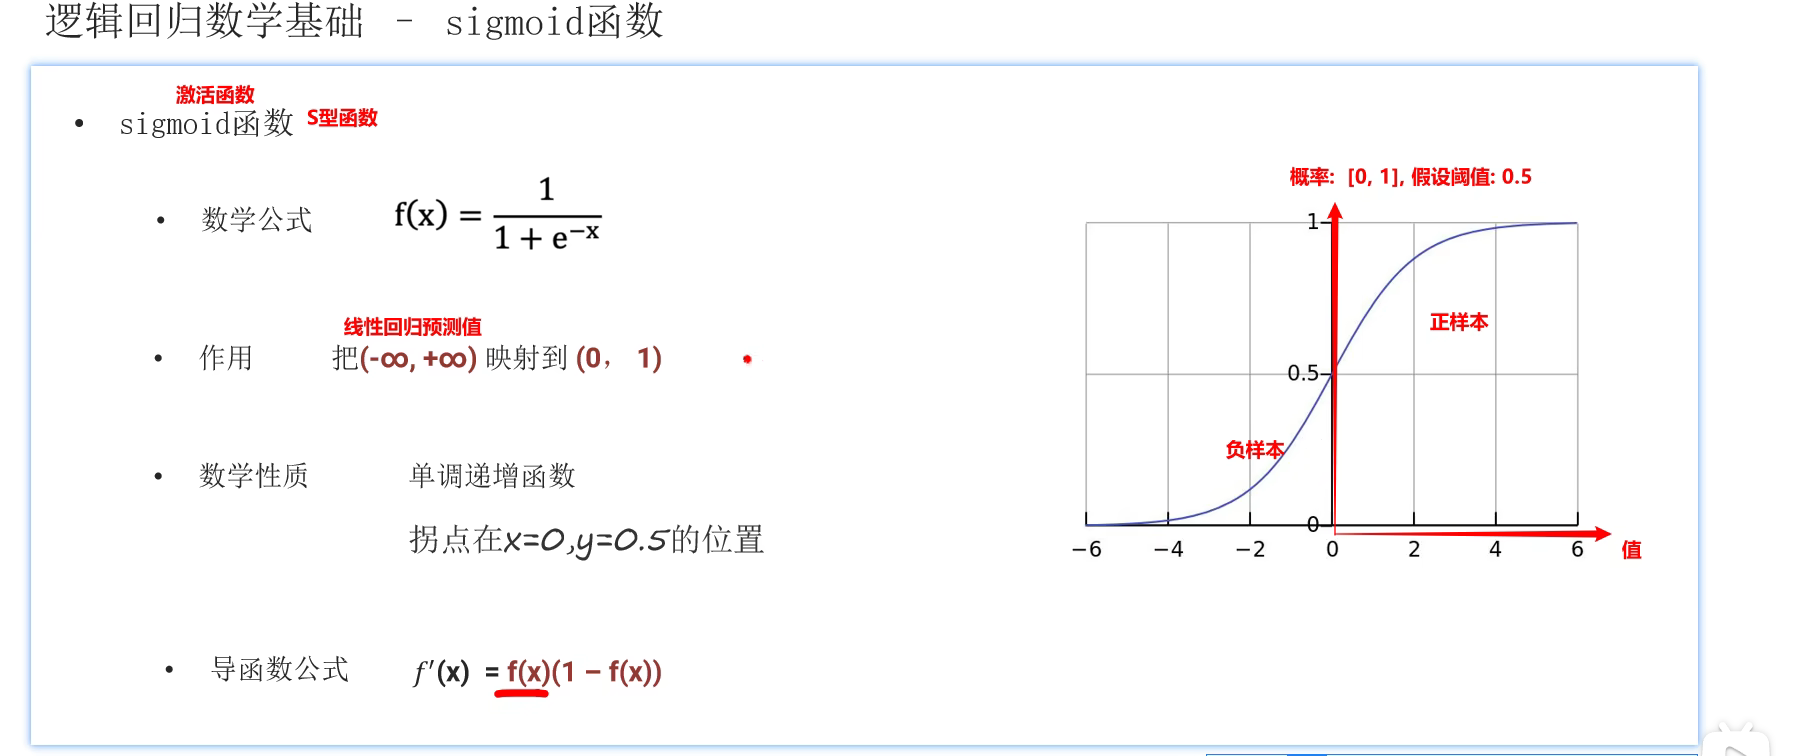

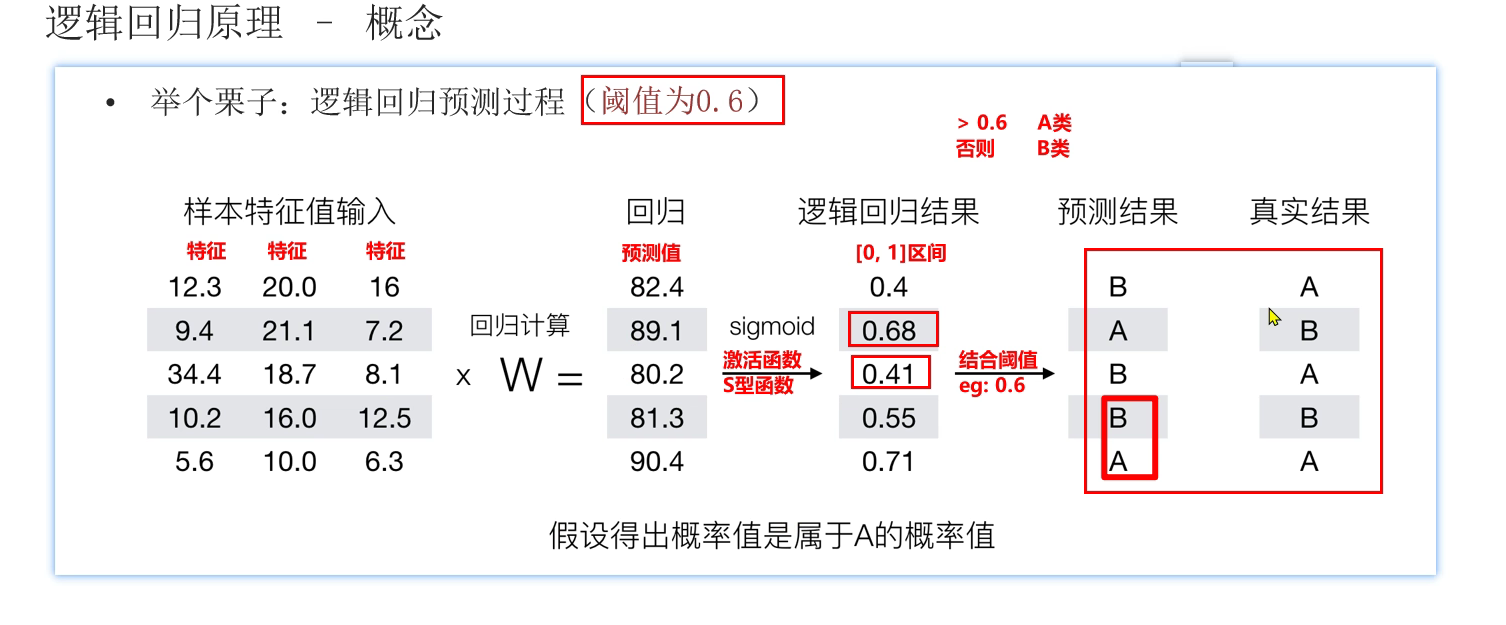

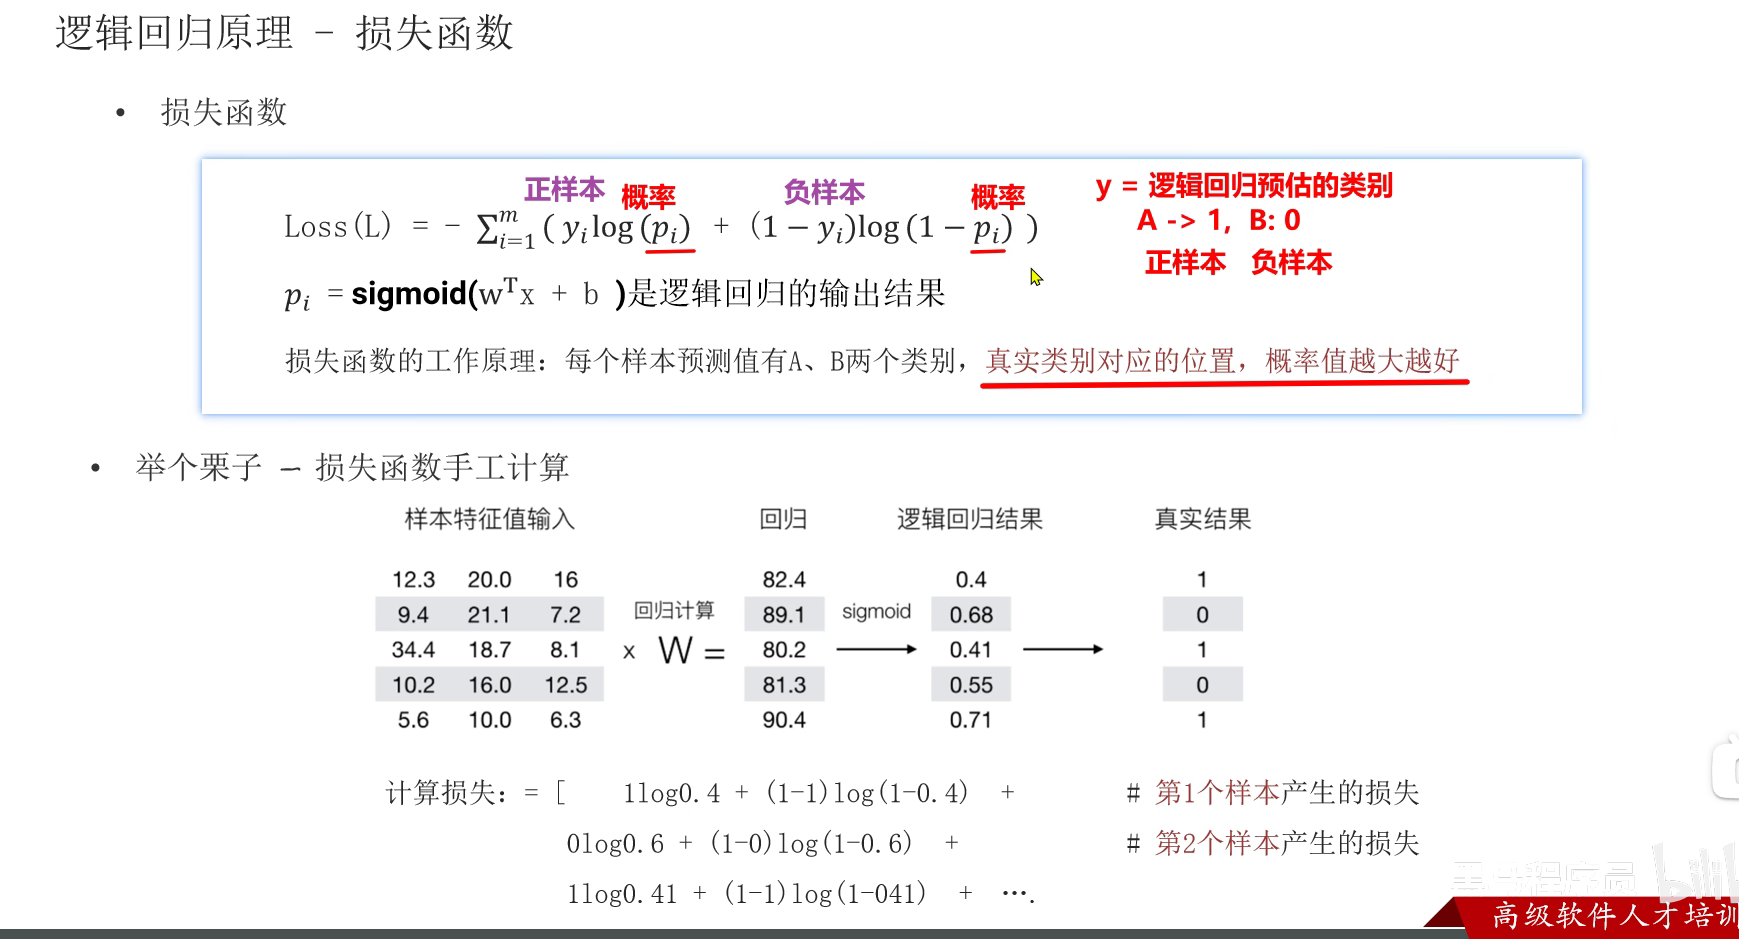

损失函数解析：
* sigmoid就是把所有预测值映射值为p=(0,1)  log函数就想成lnx yi是真实值
* 公式分成两半就是因为有俩类别  如果是正样本预测对了ln1=0损失函数为0，预测错了ln0=无穷 损失函数会特别大
* 根据损失函数的大小 来调整W
* 损失函数=-极大似然估计函数

# 逻辑回归API

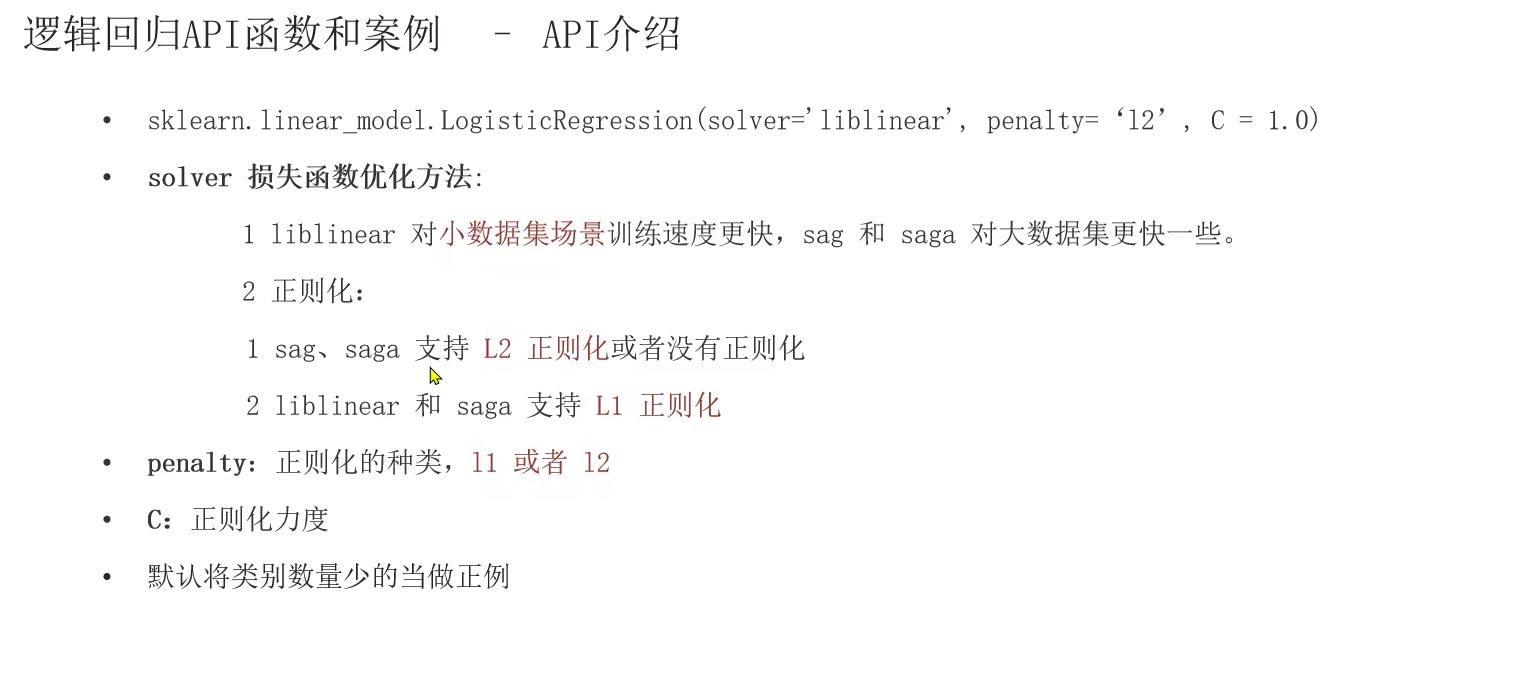

* 逻辑回归API跟线性回归没两样 就是导包把线性->逻辑 给模型对象赋值 线性->逻辑
* 下面代码别运行 我没下载数据 运行不出来


In [ ]:
"""
案例:
    演示逻辑回归模型实现 癌症预测.

逻辑回归模型介绍:
    概述:
        属于有监督学习, 即: 有特征, 有标签, 且表示是离散的.
        主要适用于: 二分类.
    原理:
        把线性回归处理后的预测值 -> 通过 Sigmoid激活函数, 映射到[0, 1] 概率 -> 基于自定义的阈值, 结合概率来 分类.
    损失函数:
        极大似然估计函数的 负数形式.

回顾: 机器学习项目流程
    1. 加载数据.
    2. 数据预处理.
    3. 特征工程(提取, 预处理...)
    4. 模型训练.
    5. 模型预测.
    6. 模型评估.
"""

# 导包
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression     # 逻辑回归模型
from sklearn.preprocessing import StandardScaler        # 标准化
from sklearn.model_selection import train_test_split    # 训练集和测试集分割
from sklearn.metrics import accuracy_score              # 模型评估

# 1. 加载数据.
data = pd.read_csv('./data/breast-cancer-wisconsin.csv')
# data.info()     # 查看数据信息

# 2. 数据预处理.
# 2.1 把 ? 替换成 np.nan,  参1: 要被替换的值,  参2: 用来替换的值,  参3: 是否替换源数据, 默认为False
data.replace('?', np.nan, inplace=True)
# 2.2 缺失值处理 -> 删除.
data.dropna(axis=0, inplace=True)   # axis=0, 表示行, 删除包含缺失值的行.
# 2.3 打印处理后的信息.
# data.info()

# 3. 特征工程(提取, 预处理...)
# 3.1 特征提取之 提取特征和标签.
x = data.iloc[:, 1:-1]  # 按照行号, 列索引获取数据,  :表示所有行   1:-1 表示从第1列到最后1列, 包左不包右
# y = data.iloc[:, -1]    # 获取最后一列
# y = data['Class']       # 获取最后一列, 效果同上
y = data.Class            # 获取最后一列, 效果同上
# 3.2 查看下特征 和 标签.
print(x[:5])
print(y[:5])
print(x.shape, y.shape)
# 3.3 切割训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)
# 3.4 特征工程: 标准化
# 3.4.1 创建标准化对象.
transfer = StandardScaler()
# 3.4.2 对训练集进行标准化.  训练 + 标准化
x_train = transfer.fit_transform(x_train)
# 3.4.3 对测试集进行标准化.  标准化
x_test = transfer.transform(x_test)

# 4. 模型训练.
# 4.1 创建模型对象 -> 逻辑回归模型
estimator = LogisticRegression(solver="lbfgs") #这一个默认配置的模型 直接正则化 等等
# 除了 lbfgs，逻辑回归其实还有其他几个候选“大脑”：都是求w和b 高配版的梯度下降
# liblinear：适合数据量非常小的时候。
# sag / saga：这是真正的“随机平均梯度下降”，当数据量达到几十万、上百万条时，它们才会比 lbfgs 更快。
# 4.2 模型训练.
estimator.fit(x_train, y_train)

# 5. 模型预测.
y_pre = estimator.predict(x_test)
print(f'预测值为: {y_pre}')

# 6. 模型评估.
# 正确率(准确率), 公式为: 预测对的 / 样本总数
print(f'预测前评估, 正确率: {estimator.score(x_test, y_test)}')     # 测试集的特征, 标签.
print(f'预测后评估, 正确率: {accuracy_score(y_test, y_pre)}')       # 测试集的标签, 预测值.

# 思考: 逻辑回归模型能用 准确率来评测吗?
# 答案: 可以, 但是结果不精准, 因为逻辑回归模型主要用于 二分类, 即: A类还是B类, 不能说 97%的A类, 3%的B类.
# 所以要通过 混淆矩阵来评测, 即: 精确率, 召回率, F1值(F1-Score), ROC曲线, AUC值.

# 混淆矩阵

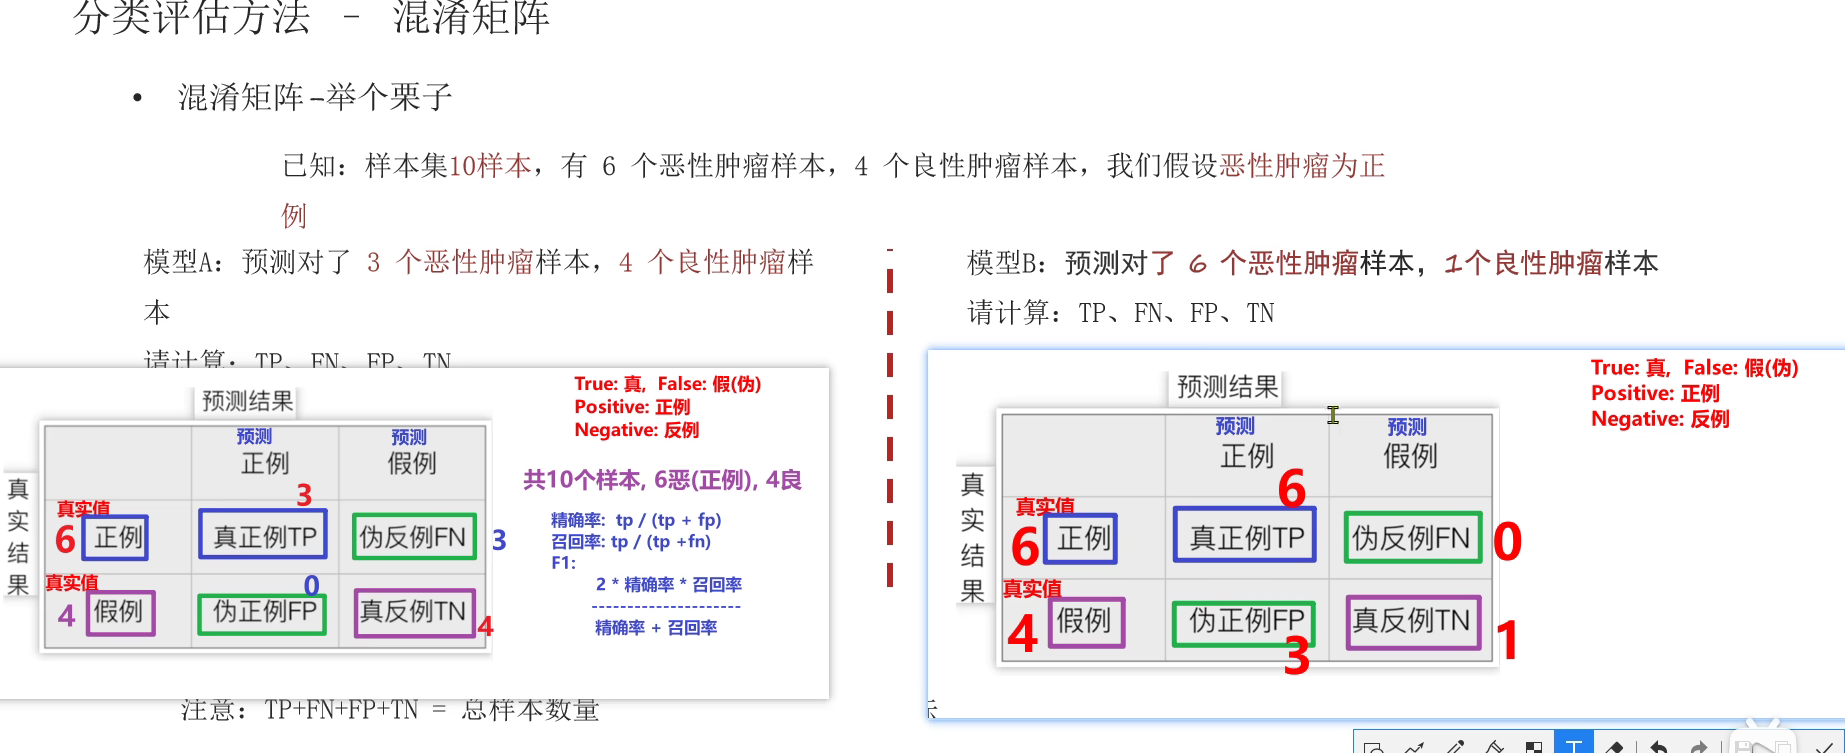

* 混淆矩阵是用来判断逻辑回归的‘准确率’，类似于线性回归的accuracy_score(真实值，预测值)

In [ ]:
"""
案例: 演示逻辑回归模型评估, 精确率, 召回率, F1值.

混淆矩阵:
    概述:
        用于展示 真实值 和 预测值之间, 正例, 反例的情况.
    默认:
        会用 分类少的 样本当做 正例.
    混淆矩阵名词解释:
                    预测值(正例)     预测值(反例)             # True(真), False(伪),   Positive(正例),  Negative(反例)
        真实值(正例)   真正例(TP)     伪反例(FN)
        真实值(反例)   伪正例(FP)     真反例(TN)

逻辑回归 评估方式:
    准确率:
        预测正确的 / 样本总数, 即:  (tp + tn) / 样本总数

    精确率(查准率, Precision):
        真正例 / (真正例 + 伪正例), 即: tp / (tp + fp)
        大白话: 真正例 在 预测为正例的结果中的 占比.

    召回率(查全率, Recall):
        真正例 / (真正例 + 伪反例), 即: tp / (tp + fn)
        大白话: 真正例 在 真实正例样本中的 占比.

    F1值(F1-Score):
        2 * 精确率 * 召回率 / (精确率 + 召回率)
        适用于: 既要考虑精确率, 还要考虑召回率的情况.

"""

# 导包
import pandas as pd
#                            混淆矩阵            精确率             召回率       F1值
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 1. 定义数据集, 表示: 真实样本(共计10个, 6个恶性, 4个良性) => 设置: 恶性(正例), 良性(反例)
y_train = ['恶性', '恶性', '恶性', '恶性', '恶性', '恶性',   '良性', '良性', '良性', '良性']

# 2. 定义标签名.
label = ['恶性', '良性']        # 正样本(正例), 负样本(反例)
df_label = ['恶性(正例)', '良性(反例)']

# 3. 定义 预测结果A, 预测对了 -> 3个恶性肿瘤, 4个良性肿瘤.
y_pre_A = ['恶性', '恶性', '恶性', '良性', '良性', '良性',   '良性', '良性', '良性', '良性']
# 4. 把上述的 预测结果A 转换成 混淆矩阵.
# 参1: 真实样本, 参2: 预测样本, 参3: 样本标签(正例, 反例)
cm_A = confusion_matrix(y_train, y_pre_A, labels=['恶性', '良性'])
#labels 这个是用于规定谁是正例 一般在前是正例
print(f'混淆矩阵A: \n {cm_A}')
# 5. 把混淆矩阵 转换成 DataFrame.
df_A = pd.DataFrame(cm_A, index=df_label, columns=df_label)
print(f'预测结果A对应的DataFrame对象: \n {df_A}')
print('-' * 22)

# 6. 定义 预测结果B, 预测对了 -> 6个恶性肿瘤, 1个良性肿瘤.
y_pre_B = ['恶性', '恶性', '恶性', '恶性', '恶性', '恶性',   '恶性', '恶性', '恶性', '良性']
# 7. 把上述的 预测结果B 转换成 混淆矩阵.
cm_B = confusion_matrix(y_train, y_pre_B, labels=label)
print(f'混淆矩阵B: \n {cm_B}')
# 8. 把混淆矩阵 转换成 DataFrame.
df_B = pd.DataFrame(cm_B, index=df_label, columns=df_label)
print(f'预测结果B对应的DataFrame对象: \n {df_B}')
print('-' * 22)

# 9.打印预测结果 y_pre_A 和 y_pre_B 的精确率, 召回率, F1值.
# 精确率, 参1: 真实样本, 参2: 预测样本, 参3: positive label: 正例标签
print(f'预测结果A的精确率: {precision_score(y_train, y_pre_A, pos_label="恶性")}')
print(f'预测结果B的精确率: {precision_score(y_train, y_pre_B, pos_label="恶性")}')

# 召回率
print(f'预测结果A的召回率: {recall_score(y_train, y_pre_A, pos_label="恶性")}')
print(f'预测结果B的召回率: {recall_score(y_train, y_pre_B, pos_label="恶性")}')

# F1值.
print(f'预测结果A的F1值: {f1_score(y_train, y_pre_A, pos_label="恶性")}')
print(f'预测结果B的F1值: {f1_score(y_train, y_pre_B, pos_label="恶性")}')